In [1]:
!pip -q install shap==0.46.0 lime==0.2.0.1 imbalanced-learn==0.12.3 fairlearn==0.10.0 scikit-learn==1.5.1 xgboost==2.1.1 matplotlib==3.9.2 plotly==5.24.0 joblib==1.4.2 seaborn


In [ ]:
import os, sys, json, time, math, joblib, numpy as np, pandas as pd
from datetime import datetime
from pathlib import Path    

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, average_precision_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap, lime
from lime.lime_tabular import LimeTabularExplainer

from imblearn.over_sampling import SMOTE
from fairlearn.metrics import MetricFrame, selection_rate, false_negative_rate, false_positive_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42


In [3]:
df1 = pd.read_csv('Heart_disease_cleveland_new.csv')
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [4]:
df2 = pd.read_csv('Heart_disease_statlog.csv')
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [5]:
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(573, 14)

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [7]:
data = df.copy()
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [8]:
df = df.copy()

# Common Cleveland/Kaggle columns; rename if needed
rename_map = {
    'cp': 'cp', 'trestbps': 'trestbps', 'chol': 'chol', 'fbs': 'fbs', 'restecg': 'restecg',
    'thalach': 'thalach', 'exang': 'exang', 'oldpeak': 'oldpeak', 'slope': 'slope',
    'ca': 'ca', 'thal': 'thal'
}
# If the dataset has 'num' as outcome (0..4), convert to binary (disease present = 1 if num>0)
if 'num' in df.columns and 'target' not in df.columns:
    df['target'] = (df['num'] > 0).astype(int)

# Convert '?' to NaN (common in 'ca' and 'thal')
df = df.replace('?', np.nan)

# Cast numerics
numeric_like = ['age','trestbps','chol','thalach','oldpeak','ca']
for c in numeric_like:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Ensure expected columns exist
expected = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang',
            'oldpeak','slope','ca','thal','target']
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nRename your columns to Cleveland names or adapt code.")

# Basic sanity
print(df.isna().sum().sort_values(ascending=False).head(10))
df['target'].value_counts(dropna=False)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
dtype: int64


target
0    314
1    259
Name: count, dtype: int64

In [9]:
# Hypertension Flag
df['hypertension'] = (df['trestbps'] > 140).astype(int)

# Cholesterol Binning (Clinical Thresholds)
df['chol_category'] = pd.cut(df['chol'], bins=[0, 200, 239, 1000], labels=['Normal','Borderline High','High'])

# Age × Chest Pain Interaction
df['age_cp'] = df['age'] * df['cp']

# Exercise-Induced Ischemia Severity (Oldpeak × Slope)
df['ischemia_severity'] = df['oldpeak'] * df['slope']

# Heart Rate Reserve (Max HR vs Expected HR)
df['hr_reserve'] = (220 - df['age']) - df['thalach']

# FBS × Age (Diabetes Risk Proxy)
df['fbs_age'] = df['fbs'] * df['age']

# Sex-Specific Interactions
# Cholesterol effect differs by sex
df['sex_chol'] = df['sex'] * df['chol']
# Chest pain differences
df['sex_cp'] = df['sex'] * df['cp']

# Risk Category Flags (Binary Clinical Features)
# Tachycardia (high HR)
df['tachycardia'] = (df['thalach'] > 100).astype(int)
# ST depression flag
df['severe_st_depression'] = (df['oldpeak'] > 2).astype(int)





In [10]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,hypertension,chol_category,age_cp,ischemia_severity,hr_reserve,fbs_age,sex_chol,sex_cp,tachycardia,severe_st_depression
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0,1,Borderline High,0,4.6,7,63,233,0,1,1
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1,1,High,201,1.5,45,0,286,3,1,0
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1,0,Borderline High,201,2.6,24,0,229,3,1,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0,0,High,74,7.0,-4,0,250,2,1,1
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0,0,Borderline High,41,0.0,7,0,0,0,1,0


In [11]:
chol_category_mapping = {'Normal': 0, 'Borderline High': 1, 'High': 2}
df['chol_category'] = df['chol_category'].map(chol_category_mapping)

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,hypertension,chol_category,age_cp,ischemia_severity,hr_reserve,fbs_age,sex_chol,sex_cp,tachycardia,severe_st_depression
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0,1,1,0,4.6,7,63,233,0,1,1
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1,1,2,201,1.5,45,0,286,3,1,0
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1,0,1,201,2.6,24,0,229,3,1,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0,0,2,74,7.0,-4,0,250,2,1,1
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0,0,1,41,0.0,7,0,0,0,1,0


In [13]:
print(df['sex'].value_counts())

sex
1    389
0    184
Name: count, dtype: int64


<Axes: >

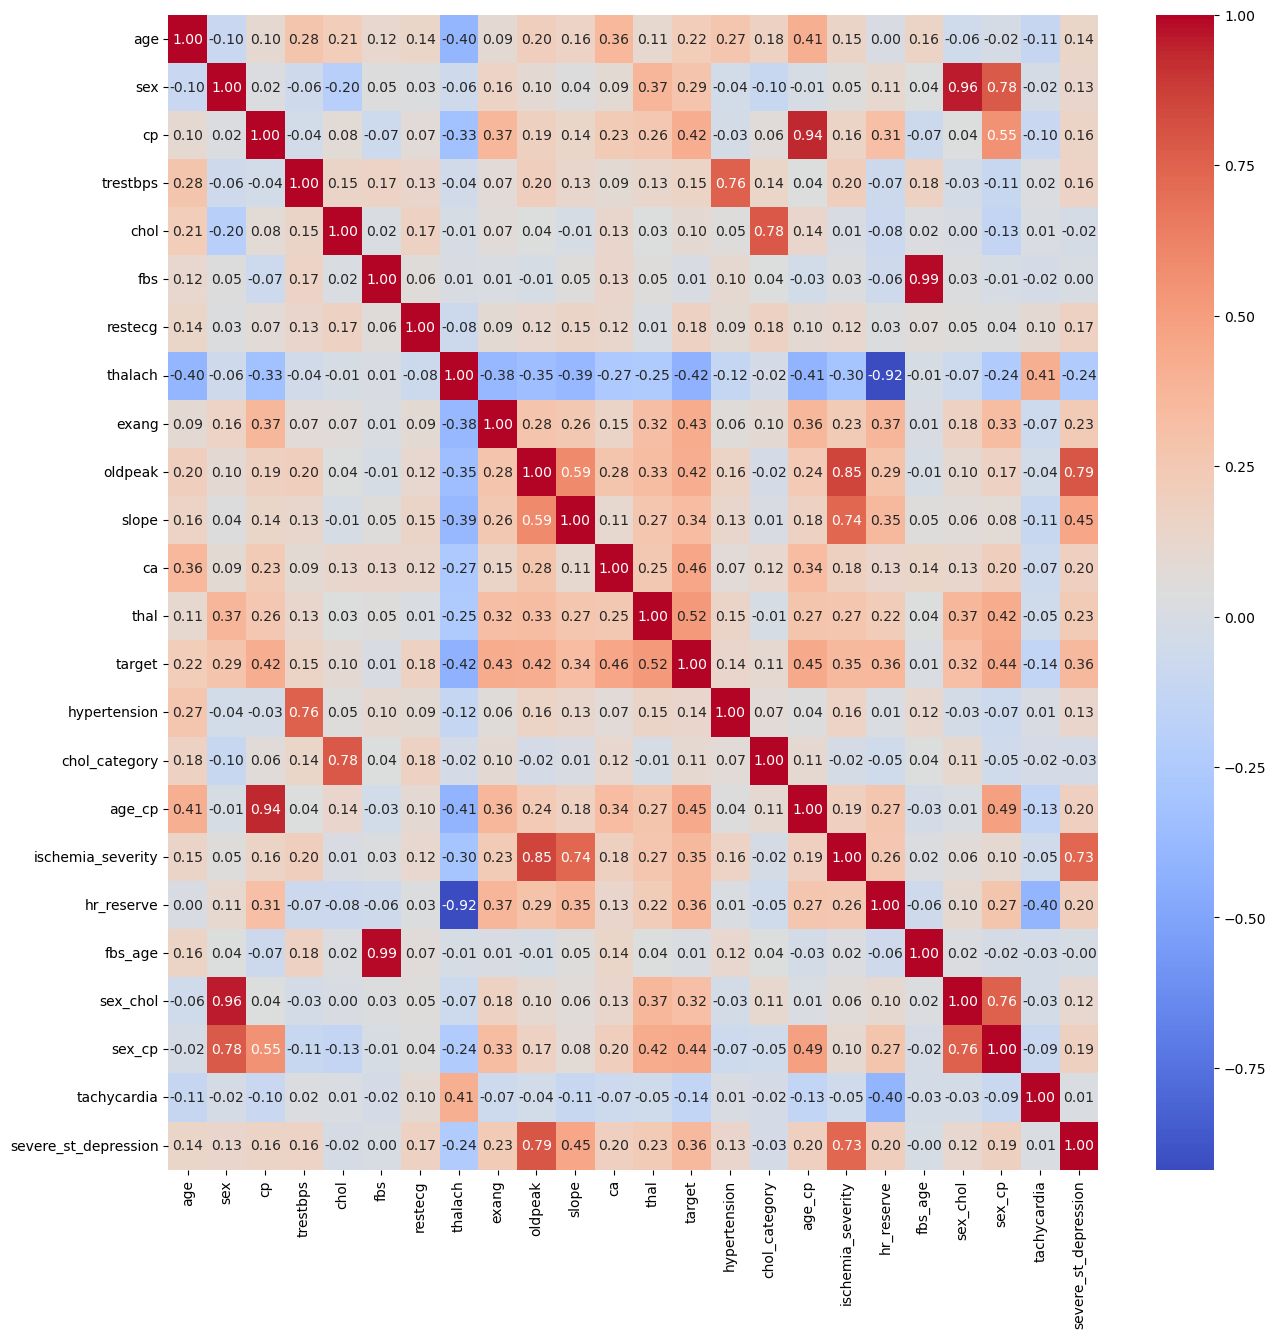

In [14]:
import seaborn as sns
corr = df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

In [15]:
X = df.drop(columns=['target'])
y = df['target'].astype(int)

In [16]:
# original Cleveland columns (adjust if yours differ)
original_cols = [
    'age','sex','cp','trestbps','chol','fbs','restecg',
    'thalach','exang','oldpeak','slope','ca','thal'
]

# anything (except target) that is not in original_cols is engineered
engineered_cols = sorted([c for c in df.columns if c not in original_cols + ['target']])
print("Engineered columns:", engineered_cols)


Engineered columns: ['age_cp', 'chol_category', 'fbs_age', 'hr_reserve', 'hypertension', 'ischemia_severity', 'severe_st_depression', 'sex_chol', 'sex_cp', 'tachycardia']


In [17]:
def eval_once(X, y, split_label, test_size):
    # Pipelines (LR needs scaling; RF does not)
    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, penalty="l2", solver="lbfgs"))
    ])
    rf_pipe = RandomForestClassifier(n_estimators=200, random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    rows = []
    for model_name, model, Xt, Xv in [
        ("Logistic Regression", lr_pipe, X_train, X_test),
        ("Random Forest", rf_pipe, X_train, X_test),
    ]:
        model.fit(Xt, y_train)
        y_pred = model.predict(Xv)
        y_proba = model.predict_proba(Xv)[:, 1]
        rows.append({
            "Split": split_label,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_proba),
        })
    return pd.DataFrame(rows)

def evaluate_feature_set(X, y, feature_label):
    # run both 80–20 and 70–30 on the same feature set
    df1 = eval_once(X, y, "80-20", 0.20)
    df2 = eval_once(X, y, "70-30", 0.30)
    out = pd.concat([df1, df2], ignore_index=True)
    out.insert(2, "Features", feature_label)  # add label column after Model
    return out

In [18]:
y = df['target']

# ORIGINAL ONLY
X_orig = df[original_cols]
res_orig = evaluate_feature_set(X_orig, y, "Original")

# ORIGINAL + ENGINEERED
X_eng = df[original_cols + engineered_cols]
res_eng = evaluate_feature_set(X_eng, y, "Original + Engineered")

# Combine & sort for readability
results_df = pd.concat([res_orig, res_eng], ignore_index=True)
results_df = results_df.sort_values(by=["Split","Model","Features"]).reset_index(drop=True)
results_df


,Split,Model,Features,Accuracy,Precision,Recall,F1,AUC
0,70-30,Logistic Regression,Original,0.802326,0.823529,0.717949,0.767123,0.876568
1,70-30,Logistic Regression,Original + Engineered,0.813953,0.848485,0.717949,0.777778,0.879705
2,70-30,Random Forest,Original,0.895349,0.968750,0.794872,0.873239,0.939648
3,70-30,Random Forest,Original + Engineered,0.877907,0.967213,0.756410,0.848921,0.946877
4,80-20,Logistic Regression,Original,0.808696,0.840909,0.711538,0.770833,0.889805
5,80-20,Logistic Regression,Original + Engineered,0.800000,0.822222,0.711538,0.762887,0.883089
6,80-20,Random Forest,Original,0.930435,1.000000,0.846154,0.916667,0.992369
7,80-20,Random Forest,Original + Engineered,0.913043,1.000000,0.807692,0.893617,0.991148


In [19]:
# 1) Choose a weighting strategy (feel free to tweak)
WEIGHT_PRESETS = {
    # Healthcare-tilted: maximize Recall first, then AUC, then F1; keep Accuracy/Precision lighter
    "recall_first": {"Recall": 0.40, "AUC": 0.30, "F1": 0.15, "Precision": 0.10, "Accuracy": 0.05},

    # Balanced view across all 5 metrics
    "balanced": {"Recall": 0.25, "AUC": 0.25, "F1": 0.20, "Precision": 0.15, "Accuracy": 0.15},

    # Discrimination-tilted: emphasize AUC most
    "auc_first": {"Recall": 0.25, "AUC": 0.40, "F1": 0.20, "Precision": 0.10, "Accuracy": 0.05},
}

def rank_runs(results_df: pd.DataFrame, weights: dict, tie_break_order=None):
    """
    Add a CompositeScore to results_df using the given weights, then return:
      - ranked_df: all rows sorted by CompositeScore desc (with Rank)
      - best_overall: top single row
      - best_by_split: best within each Split
      - best_by_model: best within each Model
      - best_by_features: best within each Features group
    """
    req_cols = {"Split","Model","Features","Accuracy","Precision","Recall","F1","AUC"}
    missing = req_cols - set(results_df.columns)
    if missing:
        raise ValueError(f"results_df missing columns: {missing}")

    # Normalize weights to be safe
    total_w = sum(weights.values())
    if abs(total_w - 1.0) > 1e-6:
        weights = {k: v/total_w for k, v in weights.items()}

    df = results_df.copy()

    # Optional: bring all metrics to [0,1] if not already (they should be)
    # If you ever add metrics on different scales, min-max them here.

    # Composite score
    df["CompositeScore"] = (
        df["Recall"]   * weights.get("Recall", 0) +
        df["AUC"]      * weights.get("AUC", 0) +
        df["F1"]       * weights.get("F1", 0) +
        df["Precision"]* weights.get("Precision", 0) +
        df["Accuracy"] * weights.get("Accuracy", 0)
    )

    # Default tie-break: prioritize Recall, then AUC, then F1, then Precision, then Accuracy
    if tie_break_order is None:
        tie_break_order = ["CompositeScore","Recall","AUC","F1","Precision","Accuracy"]

    # Sort (all descending)
    ranked_df = df.sort_values(by=tie_break_order, ascending=[False]*len(tie_break_order)).reset_index(drop=True)
    ranked_df.insert(0, "Rank", range(1, len(ranked_df)+1))

    # Best overall
    best_overall = ranked_df.iloc[0:1].copy()

    # Best per split/model/features
    best_by_split = ranked_df.sort_values(by=tie_break_order, ascending=[False]*len(tie_break_order)) \
                             .groupby("Split", as_index=False).first()
    best_by_model = ranked_df.sort_values(by=tie_break_order, ascending=[False]*len(tie_break_order)) \
                             .groupby("Model", as_index=False).first()
    best_by_features = ranked_df.sort_values(by=tie_break_order, ascending=[False]*len(tie_break_order)) \
                                .groupby("Features", as_index=False).first()

    return ranked_df, best_overall, best_by_split, best_by_model, best_by_features


# -------------------------
# USAGE EXAMPLES
# -------------------------

# Pick one strategy:
weights = WEIGHT_PRESETS["balanced"]   # "recall_first" or "balanced" or "auc_first"

ranked_df, best_overall, best_by_split, best_by_model, best_by_features = rank_runs(results_df, weights)

# See the winners
print("\n=== Top Ranked Runs ===")
print(ranked_df.head(10).to_string(index=False))

print("\n=== Best Overall ===")
print(best_overall.to_string(index=False))

print("\n=== Best By Split ===")
print(best_by_split.to_string(index=False))

print("\n=== Best By Model ===")
print(best_by_model.to_string(index=False))

print("\n=== Best By Features ===")
print(best_by_features.to_string(index=False))


=== Top Ranked Runs ===
 Rank Split               Model              Features  Accuracy  Precision   Recall       F1      AUC  CompositeScore
    1 80-20       Random Forest              Original  0.930435   1.000000 0.846154 0.916667 0.992369        0.932529
    2 80-20       Random Forest Original + Engineered  0.913043   1.000000 0.807692 0.893617 0.991148        0.915390
    3 70-30       Random Forest              Original  0.895349   0.968750 0.794872 0.873239 0.939648        0.887893
    4 70-30       Random Forest Original + Engineered  0.877907   0.967213 0.756410 0.848921 0.946877        0.872374
    5 70-30 Logistic Regression Original + Engineered  0.813953   0.848485 0.717949 0.777778 0.879705        0.804335
    6 80-20 Logistic Regression              Original  0.808696   0.840909 0.711538 0.770833 0.889805        0.801943
    7 70-30 Logistic Regression              Original  0.802326   0.823529 0.717949 0.767123 0.876568        0.795932
    8 80-20 Logistic Regression

======

In [20]:
preferred_order = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]
available = [c for c in preferred_order if c in df.columns]
assert "target" in available, "target column not found in df."

feature_cols = [c for c in available if c != "target"]

In [21]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [22]:
data.shape

(573, 14)

In [23]:
for col in ["ca","thal"]:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [24]:
# Drop rows with NaNs ONLY on needed columns
work = data.dropna(subset=feature_cols+["target"]).copy()

In [25]:
# Int-like cols to ensure correct dtype
int_like = ["sex","cp","fbs","restecg","exang","slope","ca","thal","target"]
for c in int_like:
    if c in work.columns and pd.api.types.is_numeric_dtype(work[c]):
        # round then cast (in case floats like 0.0/1.0 crept in)
        work[c] = np.round(work[c]).astype(int)

In [26]:
X = work[feature_cols].copy()
y = work["target"].astype(int).copy()

In [27]:
work.shape

(573, 14)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [30]:
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

<Figure size 640x480 with 0 Axes>

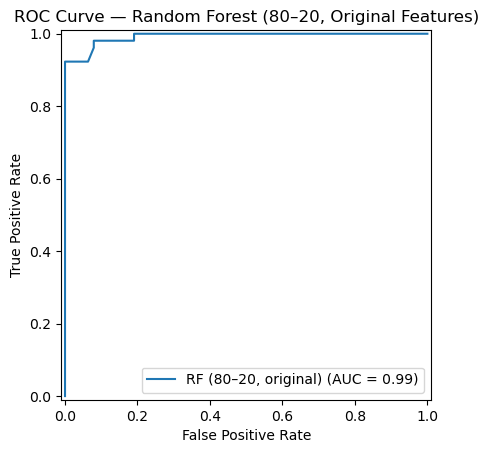

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="RF (80–20, original)").plot()
plt.title("ROC Curve — Random Forest (80–20, Original Features)")
plt.show()


<Figure size 640x480 with 0 Axes>

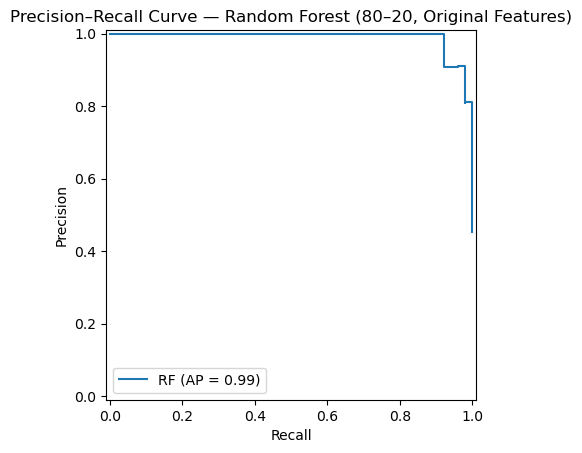

In [32]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.figure()
PrecisionRecallDisplay(precision=prec, recall=rec, average_precision=ap, estimator_name="RF").plot()
plt.title("Precision–Recall Curve — Random Forest (80–20, Original Features)")
plt.show()

<Figure size 640x480 with 0 Axes>

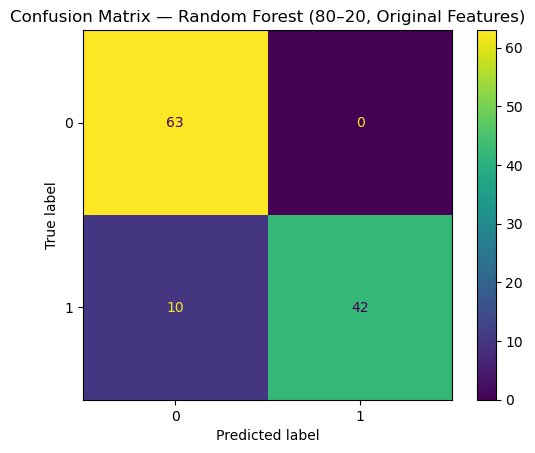

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix — Random Forest (80–20, Original Features)")
plt.show()

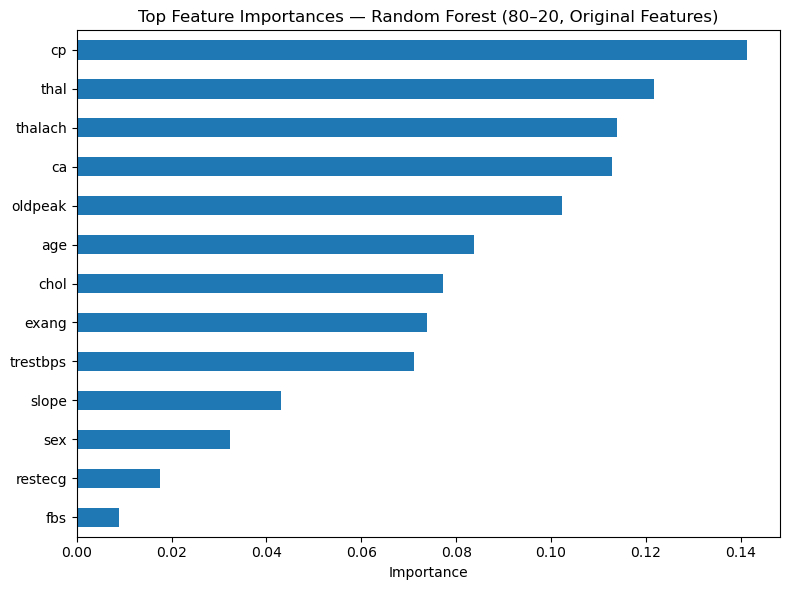

In [62]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
topk = min(15, len(importances))
plt.figure(figsize=(8, 6))
importances.head(topk).iloc[::-1].plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top Feature Importances — Random Forest (80–20, Original Features)")
plt.tight_layout()
plt.show()

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        63
           1       1.00      0.81      0.89        52

    accuracy                           0.91       115
   macro avg       0.93      0.90      0.91       115
weighted avg       0.92      0.91      0.91       115



In [36]:
SAVE_DIR = "."

X.to_csv(os.path.join(SAVE_DIR, "X_original.csv"), index=False)
y.to_csv(os.path.join(SAVE_DIR, "y_original.csv"), index=False)
X_train.to_csv(os.path.join(SAVE_DIR, "X_train_original_80_20.csv"), index=False)
X_test.to_csv(os.path.join(SAVE_DIR, "X_test_original_80_20.csv"), index=False)
y_train.to_csv(os.path.join(SAVE_DIR, "y_train_original_80_20.csv"), index=False)
y_test.to_csv(os.path.join(SAVE_DIR, "y_test_original_80_20.csv"), index=False)

print("\nSaved CSVs:")
for fn in [
    "X_original.csv","y_original.csv",
    "X_train_original_80_20.csv","X_test_original_80_20.csv",
    "y_train_original_80_20.csv","y_test_original_80_20.csv"
]:
    print(" -", os.path.join(SAVE_DIR, fn))

print("\nShapes:")
print("X:", X.shape, "y:", y.shape)
print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)


Saved CSVs:
 - .\X_original.csv
 - .\y_original.csv
 - .\X_train_original_80_20.csv
 - .\X_test_original_80_20.csv
 - .\y_train_original_80_20.csv
 - .\y_test_original_80_20.csv

Shapes:
X: (573, 13) y: (573,)
X_train: (458, 13) X_test: (115, 13) y_train: (458,) y_test: (115,)


In [37]:
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)


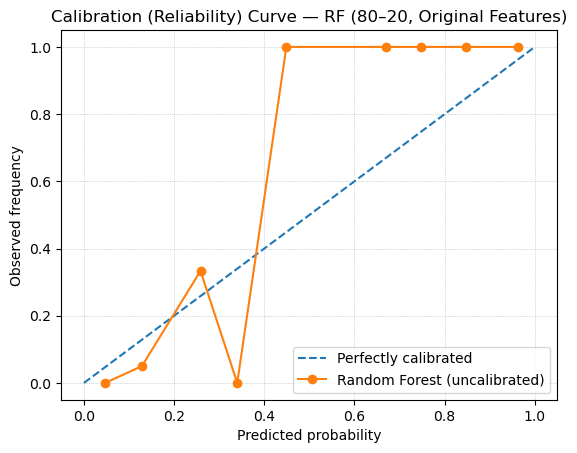

In [38]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Bin predictions and compare predicted vs observed event rate
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="uniform")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.plot(prob_pred, prob_true, marker="o", label="Random Forest (uncalibrated)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration (Reliability) Curve — RF (80–20, Original Features)")
plt.legend(loc="best")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()


In [39]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Fit calibrated versions
rf_sigmoid = CalibratedClassifierCV(rf, method="sigmoid", cv=5)
rf_sigmoid.fit(X_train, y_train)
proba_sigmoid = rf_sigmoid.predict_proba(X_test)[:, 1]

rf_iso = CalibratedClassifierCV(rf, method="isotonic", cv=5)
rf_iso.fit(X_train, y_train)
proba_iso = rf_iso.predict_proba(X_test)[:, 1]

# Compare Brier scores (lower is better)
print("Uncalibrated Brier:", brier_score_loss(y_test, y_proba))
print("Sigmoid Brier:     ", brier_score_loss(y_test, proba_sigmoid))
print("Isotonic Brier:    ", brier_score_loss(y_test, proba_iso))


Uncalibrated Brier: 0.05578193236714975
Sigmoid Brier:      0.05827197391468
Isotonic Brier:     0.05007955774263846


In [40]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate your already-fitted RF on the training split
rf_iso = CalibratedClassifierCV(rf, method="isotonic", cv=5)
rf_iso.fit(X_train, y_train)

# Calibrated probabilities on test
proba_cal = rf_iso.predict_proba(X_test)[:, 1]
pred_cal  = (proba_cal >= 0.5).astype(int)  # default threshold; we’ll examine thresholds next


In [41]:
import pandas as pd
import numpy as np

risk_bins = [0.0, 0.20, 0.50, 1.0]
risk_labels = ["Low (<20%)", "Moderate (20–50%)", "High (>50%)"]

risk_cat = pd.cut(proba_cal, bins=risk_bins, labels=risk_labels, include_lowest=True)

risk_report = pd.DataFrame({
    "TrueLabel": y_test.values,
    "CalibratedProb": proba_cal,
    "RiskCategory": risk_cat
})
risk_report.index.name = "PatientID"

risk_report.head(10)


,TrueLabel,CalibratedProb,RiskCategory
PatientID,,,
0,1,0.975325,High (>50%)
1,0,0.000000,Low (<20%)
2,0,0.146667,Low (<20%)
3,1,0.273391,Moderate (20–50%)
4,1,0.400761,Moderate (20–50%)
5,1,0.273391,Moderate (20–50%)
6,0,0.022857,Low (<20%)
7,0,0.013333,Low (<20%)
8,1,1.000000,High (>50%)


In [42]:
# Distribution of patients by risk category
risk_counts = risk_report["RiskCategory"].value_counts().reindex(risk_labels)
print("Patients per risk band:\n", risk_counts, "\n")

# Positive rate inside each risk band (how many actually had disease)
band_outcomes = (
    risk_report.groupby("RiskCategory")["TrueLabel"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n", "mean": "ObservedPosRate"})
    .reindex(risk_labels)
)
band_outcomes


Patients per risk band:
 RiskCategory
Low (<20%)           62
Moderate (20–50%)     9
High (>50%)          44
Name: count, dtype: int64 



C:\Users\Jyothi\AppData\Local\Temp\ipykernel_4292\1954313715.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_report.groupby("RiskCategory")["TrueLabel"]


,n,ObservedPosRate
RiskCategory,,
Low (<20%),62,0.032258
Moderate (20–50%),9,0.666667
High (>50%),44,1.000000


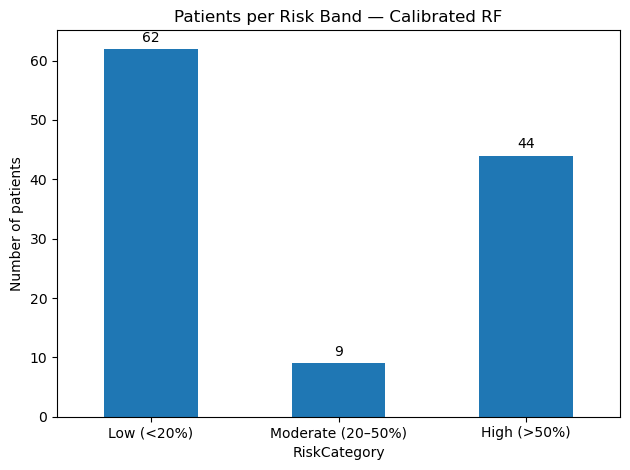

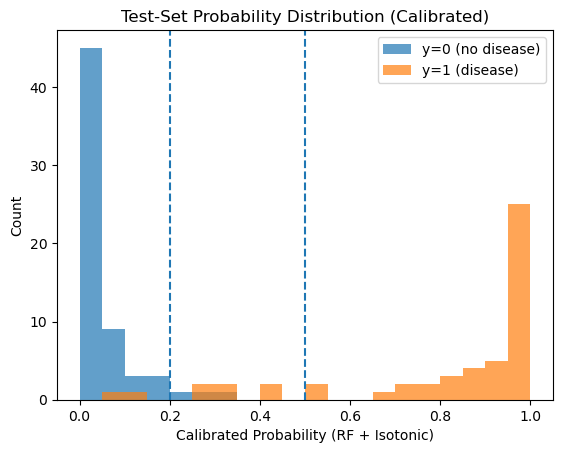

In [59]:
import matplotlib.pyplot as plt

# (A) Bar plot: patients per risk band
plt.figure()
ax = risk_counts.plot(kind="bar")
plt.ylabel("Number of patients")
plt.title("Patients per Risk Band — Calibrated RF")
plt.xticks(rotation=0)

# annotate counts on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",              # text = bar height
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=10, color='black', xytext=(0,3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# (B) Probability histogram by class
proba_pos = proba_cal[y_test.values == 1]
proba_neg = proba_cal[y_test.values == 0]

bins = np.linspace(0, 1, 21)
plt.figure()
plt.hist(proba_neg, bins=bins, alpha=0.7, label="y=0 (no disease)")
plt.hist(proba_pos, bins=bins, alpha=0.7, label="y=1 (disease)")

# draw risk band cutoffs
for x in [0.20, 0.50]:
    plt.axvline(x, linestyle="--")

plt.xlabel("Calibrated Probability (RF + Isotonic)")
plt.ylabel("Count")
plt.title("Test-Set Probability Distribution (Calibrated)")
plt.legend()
plt.show()


In [44]:
# Top-10 highest risk
top_high = risk_report.sort_values("CalibratedProb", ascending=False).head(10)
top_high

# Patients close to 0.50 (±0.03) – may warrant attention
near_050 = risk_report[np.abs(risk_report["CalibratedProb"] - 0.50) <= 0.03].sort_values("CalibratedProb", ascending=False)
near_050.head(15)


,TrueLabel,CalibratedProb,RiskCategory
PatientID,,,


In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def threshold_table(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.1, 0.9, 17)
    rows = []
    for t in grid:
        pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": round(float(t), 2),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall":    recall_score(y_true, pred, zero_division=0),
            "f1":        f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

thr_df = threshold_table(y_test.values, proba_cal)
thr_df


,threshold,precision,recall,f1
0,0.10,0.850000,0.980769,0.910714
1,0.15,0.892857,0.961538,0.925926
2,0.20,0.943396,0.961538,0.952381
3,0.25,0.961538,0.961538,0.961538
4,0.30,0.979592,0.923077,0.950495
5,0.35,1.000000,0.884615,0.938776
6,0.40,1.000000,0.884615,0.938776
7,0.45,1.000000,0.846154,0.916667
8,0.50,1.000000,0.846154,0.916667
9,0.55,1.000000,0.807692,0.893617


In [46]:
out_dir = "."
risk_report.to_csv(f"{out_dir}/risk_report_calibrated_rf_80_20.csv")
band_outcomes.to_csv(f"{out_dir}/risk_bands_summary.csv")
thr_df.to_csv(f"{out_dir}/threshold_sweep_calibrated.csv", index=False)

print("Saved:\n- risk_report_calibrated_rf_80_20.csv\n- risk_bands_summary.csv\n- threshold_sweep_calibrated.csv")


Saved:
- risk_report_calibrated_rf_80_20.csv
- risk_bands_summary.csv
- threshold_sweep_calibrated.csv


In [47]:
rf_iso = CalibratedClassifierCV(rf, method="isotonic", cv=5).fit(X_train, y_train)
proba_cal = rf_iso.predict_proba(X_test)[:, 1]


In [48]:
# --- Pick the SAME feature set you trained RF on ---
feature_cols = list(X_train.columns)

# Split continuous vs categorical (adjust if your schema differs)
continuous_features = [c for c in feature_cols if c in ["age","trestbps","chol","thalach","oldpeak","ca"]]
categorical_features = [c for c in feature_cols if c not in continuous_features]

# DiCE needs a single DataFrame with X + y for 'data'
train_df_for_dice = X_train.copy()
train_df_for_dice["target"] = y_train.values

import dice_ml

d = dice_ml.Data(
    dataframe=train_df_for_dice,
    continuous_features=continuous_features,
    outcome_name="target"
)

# rf_iso must support predict_proba (it does)
m = dice_ml.Model(model=rf_iso, backend="sklearn")

# 'random' is the most version-stable method
exp = dice_ml.Dice(d, m, method="random")

# ---- Choose one test patient to explain ----
test_idx = X_test.index[0]
query_instance = X_test.loc[[test_idx]]

# (Fix the warning by indexing a scalar)
print("Chosen patient index:", test_idx)
print("Calibrated risk (RF+isotonic):", rf_iso.predict_proba(query_instance)[:, 1][0])

# ---- Generate counterfactuals (no proximity/diversity kwargs) ----
# Tip: some versions accept desired_class="opposite"; others accept "0"/"1".
pred_label = int((rf_iso.predict_proba(query_instance)[:, 1][0]) >= 0.5)
desired = "opposite"  # fallback below if needed:
# desired = 1 - pred_label    # <-- uncomment if your DiCE version prefers a numeric class

cf = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class=desired,
    features_to_vary="all"
)

cf_df = cf.cf_examples_list[0].final_cfs_df
cf_df


Chosen patient index: 423
Calibrated risk (RF+isotonic): 0.9753246753246753


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\Jyothi\anaconda3\Lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
c:\Users\Jyothi\anaconda3\Lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
c:\Users\Jyothi\anaconda3\Lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible d

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,49,1,2,120,188,0,0,194,0,2.0,1,0,3,0
1,49,1,2,120,188,0,0,147,0,2.0,1,0,3,0
2,49,0,2,120,188,0,0,139,0,2.0,1,0,3,0


In [49]:
orig_row = query_instance.iloc[0]
delta_rows = []
for _, row in cf_df.iterrows():
    diffs = {}
    for col in feature_cols:
        if col in row and col in orig_row and row[col] != orig_row[col]:
            diffs[col] = f"{orig_row[col]} → {row[col]}"
    delta_rows.append(diffs if diffs else {"note": "No changes"})
pd.DataFrame(delta_rows)


,thalach,ca,sex
0,139.0 → 194.0,3.0 → 0.0,NaN
1,139.0 → 147.0,3.0 → 0.0,NaN
2,NaN,3.0 → 0.0,1.0 → 0.0


Surrogate fidelity vs RF decisions @ threshold 0.3: 0.817

Surrogate vs RF decision confusion matrix on TEST:
Surrogate   0   1
RF               
0          61   5
1          16  33

=== Surrogate Rules (max_depth=3) ===
|--- cp <= 2.50
|   |--- oldpeak <= 1.95
|   |   |--- thal <= 1.50
|   |   |   |--- class: 0
|   |   |--- thal >  1.50
|   |   |   |--- class: 0
|   |--- oldpeak >  1.95
|   |   |--- class: 1
|--- cp >  2.50
|   |--- thal <= 1.50
|   |   |--- ca <= 0.50
|   |   |   |--- class: 0
|   |   |--- ca >  0.50
|   |   |   |--- class: 1
|   |--- thal >  1.50
|   |   |--- oldpeak <= 0.55
|   |   |   |--- class: 1
|   |   |--- oldpeak >  0.55
|   |   |   |--- class: 1



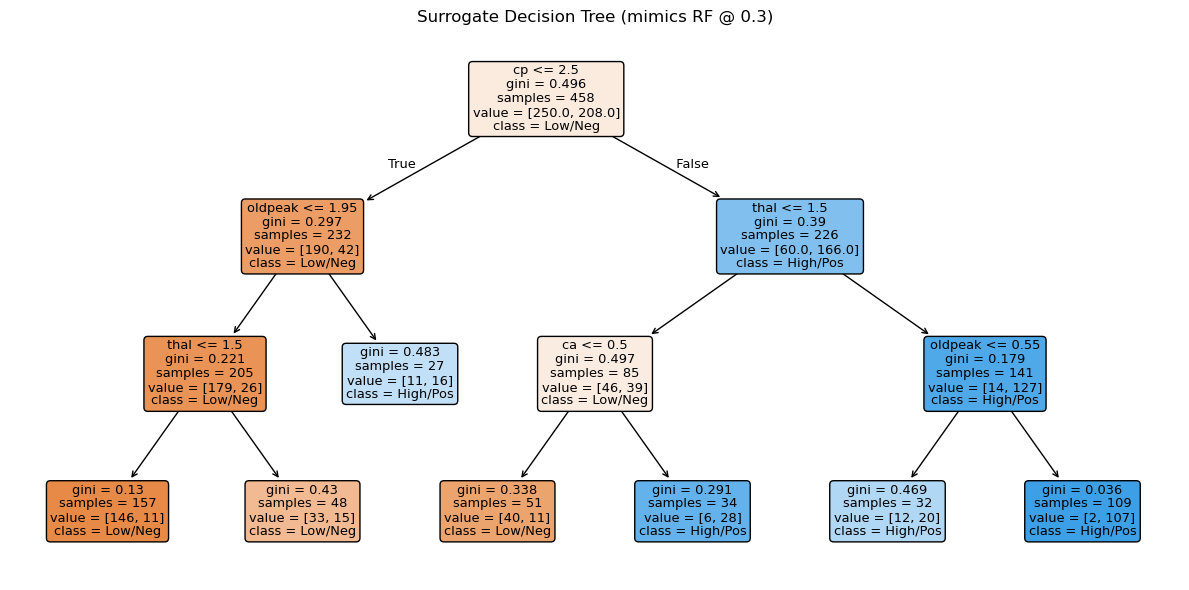


Saved:
 - outputs/surrogate_tree_rf_threshold.png
 - outputs/surrogate_rules_rf_threshold.txt


In [50]:
# ===== Surrogate rule model to mimic RF (doctor-friendly IF–THEN rules) =====
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 0) Choose a clinical threshold (pick from your sweep; 0.30 was a good balance)
THRESHOLD = 0.30

# 1) Create RF "decisions" (labels) using calibrated probabilities at chosen threshold
y_rf_train = (rf_iso.predict_proba(X_train)[:, 1] >= THRESHOLD).astype(int)
y_rf_test  = (proba_cal >= THRESHOLD).astype(int)

# 2) Fit a shallow surrogate tree to imitate RF decisions
surrogate = DecisionTreeClassifier(
    max_depth=3,           # keep it small for readability
    min_samples_leaf=20,   # smooth rules a bit
    random_state=42
)
surrogate.fit(X_train, y_rf_train)

# 3) Evaluate fidelity: how well the surrogate matches RF decisions
y_sur_test = surrogate.predict(X_test)
fidelity = accuracy_score(y_rf_test, y_sur_test)
print(f"Surrogate fidelity vs RF decisions @ threshold {THRESHOLD}: {fidelity:.3f}")
print("\nSurrogate vs RF decision confusion matrix on TEST:")
print(pd.crosstab(pd.Series(y_rf_test, name="RF_decision"),
                  pd.Series(y_sur_test, name="Surrogate"),
                  rownames=["RF"], colnames=["Surrogate"]))

# 4) Show text rules
rules_txt = export_text(surrogate, feature_names=list(X_test.columns))
print("\n=== Surrogate Rules (max_depth=3) ===")
print(rules_txt)

# 5) Visualize and save the tree
os.makedirs("outputs", exist_ok=True)
plt.figure(figsize=(12, 6))
plot_tree(
    surrogate,
    feature_names=list(X_test.columns),
    class_names=["Low/Neg", "High/Pos"],
    filled=True, rounded=True
)
plt.title(f"Surrogate Decision Tree (mimics RF @ {THRESHOLD})")
plt.tight_layout()
plt.savefig("outputs/surrogate_tree_rf_threshold.png", dpi=180)
plt.show()

# 6) Save rules to a .txt for your paper appendix
with open("outputs/surrogate_rules_rf_threshold.txt", "w") as f:
    f.write(f"Threshold: {THRESHOLD}\n")
    f.write(f"Fidelity (test): {fidelity:.3f}\n\n")
    f.write(rules_txt)

print("\nSaved:")
print(" - outputs/surrogate_tree_rf_threshold.png")
print(" - outputs/surrogate_rules_rf_threshold.txt")


In [51]:
# ===== Surrogate rule model: FULL tree + PRUNED (best alpha) =====
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------------
# 0) Config
THRESHOLD = 0.30
OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------------
# 1) Make RF "decisions" (labels) at chosen threshold
y_rf_train = (rf_iso.predict_proba(X_train)[:, 1] >= THRESHOLD).astype(int)
y_rf_test  = (proba_cal >= THRESHOLD).astype(int)

# Optional: carve out a small validation set from TRAIN just for pruning selection
X_tr, X_val, y_rf_tr, y_rf_val = train_test_split(
    X_train, y_rf_train, test_size=0.2, random_state=42, stratify=y_rf_train
)

# ------------------------------------------------------------------
# 2A) FULL surrogate tree (no depth limit)
surrogate_full = DecisionTreeClassifier(
    max_depth=None,        # <- entire tree
    min_samples_leaf=1,    # let it grow fully
    random_state=42
)
surrogate_full.fit(X_tr, y_rf_tr)

# Evaluate fidelity
y_sur_test_full = surrogate_full.predict(X_test)
fidelity_full = accuracy_score(y_rf_test, y_sur_test_full)

print(f"[FULL] Surrogate fidelity vs RF decisions @ threshold {THRESHOLD}: {fidelity_full:.3f}")
print("\n[FULL] Surrogate vs RF decision confusion matrix on TEST:")
print(pd.crosstab(pd.Series(y_rf_test, name="RF_decision"),
                  pd.Series(y_sur_test_full, name="Surrogate"),
                  rownames=["RF"], colnames=["Surrogate"]))

# Export full rules (warning: can be very long)
rules_txt_full = export_text(surrogate_full, feature_names=list(X_train.columns))
with open(os.path.join(OUTDIR, "surrogate_rules_rf_FULL.txt"), "w") as f:
    f.write(f"Threshold: {THRESHOLD}\n")
    f.write(f"Fidelity (test): {fidelity_full:.3f}\n\n")
    f.write(rules_txt_full)

# Visualize full tree (may be huge; image might be large)
plt.figure(figsize=(20, 10))
plot_tree(
    surrogate_full,
    feature_names=list(X_train.columns),
    class_names=["Low/Neg", "High/Pos"],
    filled=True, rounded=True, fontsize=6
)
plt.title(f"Surrogate Decision Tree - FULL (mimics RF @ {THRESHOLD})")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "surrogate_tree_rf_FULL.png"), dpi=180)
plt.close()

print("\nSaved FULL tree:")
print(" - outputs/surrogate_tree_rf_FULL.png")
print(" - outputs/surrogate_rules_rf_FULL.txt")

# ------------------------------------------------------------------
# 2B) COST-COMPLEXITY PRUNING to pick a compact tree that best matches RF
#     We choose alpha to maximize fidelity on the VALIDATION set (vs RF decisions).
path = surrogate_full.cost_complexity_pruning_path(X_tr, y_rf_tr)
ccp_alphas = path.ccp_alphas

best_alpha = None
best_val_fid = -np.inf
best_clf = None

val_records = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        max_depth=None,
        min_samples_leaf=1
    )
    clf.fit(X_tr, y_rf_tr)
    # Fidelity measured vs RF decisions on validation
    val_pred = clf.predict(X_val)
    val_fid = accuracy_score(y_rf_val, val_pred)
    val_records.append((alpha, val_fid, clf.get_depth(), clf.get_n_leaves()))
    if val_fid > best_val_fid:
        best_val_fid = val_fid
        best_alpha = alpha
        best_clf = clf

print(f"\n[PRUNED] Best alpha by RF-fidelity on VAL: {best_alpha:.6f} (val fidelity={best_val_fid:.3f})")

# Evaluate the chosen pruned tree on TEST
y_sur_test_pruned = best_clf.predict(X_test)
fidelity_pruned = accuracy_score(y_rf_test, y_sur_test_pruned)

print(f"[PRUNED] Surrogate fidelity vs RF decisions @ threshold {THRESHOLD}: {fidelity_pruned:.3f}")
print("\n[PRUNED] Surrogate vs RF decision confusion matrix on TEST:")
print(pd.crosstab(pd.Series(y_rf_test, name="RF_decision"),
                  pd.Series(y_sur_test_pruned, name="Surrogate"),
                  rownames=["RF"], colnames=["Surrogate"]))

# Export pruned rules
rules_txt_pruned = export_text(best_clf, feature_names=list(X_train.columns))
with open(os.path.join(OUTDIR, "surrogate_rules_rf_PRUNED.txt"), "w") as f:
    f.write(f"Threshold: {THRESHOLD}\n")
    f.write(f"Alpha chosen: {best_alpha}\n")
    f.write(f"Depth: {best_clf.get_depth()}, Leaves: {best_clf.get_n_leaves()}\n")
    f.write(f"Fidelity (val): {best_val_fid:.3f}\n")
    f.write(f"Fidelity (test): {fidelity_pruned:.3f}\n\n")
    f.write(rules_txt_pruned)

# Visualize pruned tree
plt.figure(figsize=(16, 8))
plot_tree(
    best_clf,
    feature_names=list(X_train.columns),
    class_names=["Low/Neg", "High/Pos"],
    filled=True, rounded=True
)
plt.title(f"Surrogate Decision Tree - PRUNED (alpha={best_alpha:.6f}, mimics RF @ {THRESHOLD})")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "surrogate_tree_rf_PRUNED.png"), dpi=180)
plt.close()

# Also dump the alpha vs fidelity trace for transparency
alpha_df = pd.DataFrame(val_records, columns=["ccp_alpha", "val_fidelity", "depth", "n_leaves"])
alpha_df.to_csv(os.path.join(OUTDIR, "surrogate_alpha_sweep.csv"), index=False)

print("\nSaved PRUNED tree + sweep:")
print(" - outputs/surrogate_tree_rf_PRUNED.png")
print(" - outputs/surrogate_rules_rf_PRUNED.txt")
print(" - outputs/surrogate_alpha_sweep.csv")

# Optional: quick look at how many rules/leaves you ended up with
print(f"\n[SUMMARY] FULL: depth={surrogate_full.get_depth()}, leaves={surrogate_full.get_n_leaves()}, test_fid={fidelity_full:.3f}")
print(f"[SUMMARY] PRUNED: depth={best_clf.get_depth()}, leaves={best_clf.get_n_leaves()}, test_fid={fidelity_pruned:.3f}")


[FULL] Surrogate fidelity vs RF decisions @ threshold 0.3: 0.878

[FULL] Surrogate vs RF decision confusion matrix on TEST:
Surrogate   0   1
RF               
0          58   8
1           6  43

Saved FULL tree:
 - outputs/surrogate_tree_rf_FULL.png
 - outputs/surrogate_rules_rf_FULL.txt

[PRUNED] Best alpha by RF-fidelity on VAL: 0.002618 (val fidelity=0.935)
[PRUNED] Surrogate fidelity vs RF decisions @ threshold 0.3: 0.870

[PRUNED] Surrogate vs RF decision confusion matrix on TEST:
Surrogate   0   1
RF               
0          59   7
1           8  41

Saved PRUNED tree + sweep:
 - outputs/surrogate_tree_rf_PRUNED.png
 - outputs/surrogate_rules_rf_PRUNED.txt
 - outputs/surrogate_alpha_sweep.csv

[SUMMARY] FULL: depth=8, leaves=47, test_fid=0.878
[SUMMARY] PRUNED: depth=8, leaves=41, test_fid=0.870


Performance by Sex (0=female, 1=male):


,accuracy,precision,recall,f1,selection_rate
sex,,,,,
0,0.944444,1.00000,0.777778,0.875000,0.194444
1,0.962025,0.97619,0.953488,0.964706,0.531646



Performance by Age (<50=0, ≥50=1):


,accuracy,precision,recall,f1,selection_rate
age50,,,,,
0,1.000000,1.000000,1.000000,1.000000,0.392857
1,0.942529,0.973684,0.902439,0.936709,0.436782



AUC by Sex (0=female, 1=male): {0: 1.0, 1: 0.9870801033591732}
AUC by Age (0=<50, 1=≥50): {0: 1.0, 1: 0.9875397667020148}


C:\Users\Jyothi\AppData\Local\Temp\ipykernel_4292\708482338.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_by_sex = eval_df.groupby("sex").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
C:\Users\Jyothi\AppData\Local\Temp\ipykernel_4292\708482338.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_by_age = eval_df.groupby("age50").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"

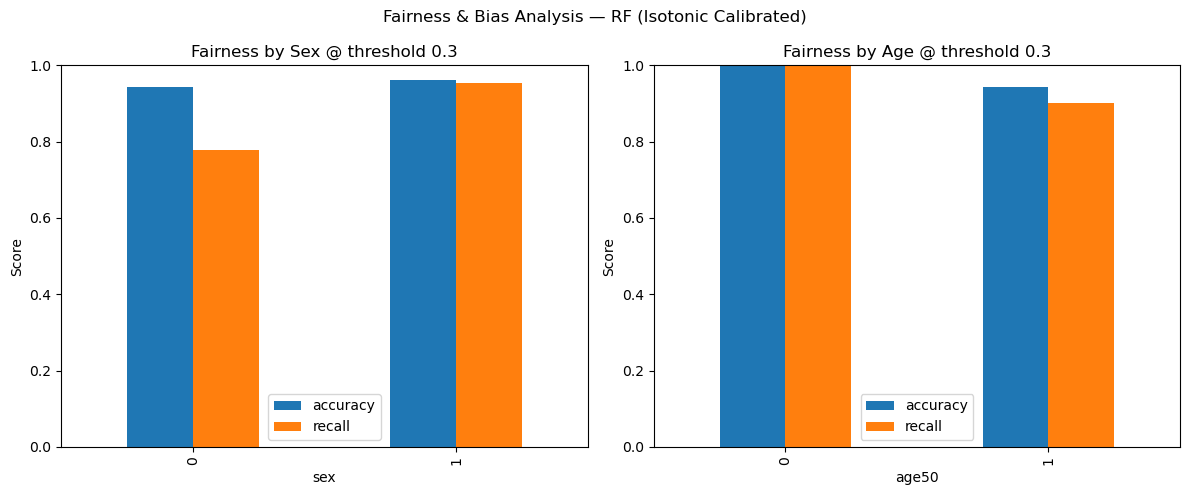

In [52]:
# ===== Fairness & Bias Analysis (Calibrated RF) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# --- 1) Calibrated probabilities + predictions (choose your clinical threshold) ---
THRESHOLD = 0.30
y_proba_cal = rf_iso.predict_proba(X_test)[:, 1]
y_pred_cal  = (y_proba_cal >= THRESHOLD).astype(int)

# --- 2) Build a position-aligned evaluation frame to avoid index misalignment ---
eval_df = pd.DataFrame({
    "y_true": y_test.reset_index(drop=True).values,
    "y_prob": pd.Series(y_proba_cal),        # positional
    "y_pred": pd.Series(y_pred_cal),
    "sex":    X_test["sex"].reset_index(drop=True).astype(int).values,        # 0=female, 1=male
    "age50":  (X_test["age"] >= 50).reset_index(drop=True).astype(int).values # 0=<50, 1=≥50
})

# --- 3) MetricFrame metrics supported without probabilities ---
metrics = {
    "accuracy": accuracy_score,
    "precision": lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score,
    "f1": f1_score,
    "selection_rate": selection_rate,
}

# --- 4) Evaluate fairness by Sex (0=female, 1=male) ---
mf_sex = MetricFrame(
    metrics=metrics,
    y_true=eval_df["y_true"],
    y_pred=eval_df["y_pred"],
    sensitive_features=eval_df["sex"]
)
print("Performance by Sex (0=female, 1=male):")
display(mf_sex.by_group)

# --- 5) Evaluate fairness by Age group (0=<50, 1=≥50) ---
mf_age = MetricFrame(
    metrics=metrics,
    y_true=eval_df["y_true"],
    y_pred=eval_df["y_pred"],
    sensitive_features=eval_df["age50"]
)
print("\nPerformance by Age (<50=0, ≥50=1):")
display(mf_age.by_group)

# --- 6) AUC by subgroup (computed separately with probabilities) ---
auc_by_sex = eval_df.groupby("sex").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
auc_by_age = eval_df.groupby("age50").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
print("\nAUC by Sex (0=female, 1=male):", auc_by_sex.to_dict())
print("AUC by Age (0=<50, 1=≥50):", auc_by_age.to_dict())

# --- 7) Visualize disparities (accuracy & recall) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mf_sex.by_group[["accuracy", "recall"]].plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Fairness by Sex @ threshold {THRESHOLD}")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)

mf_age.by_group[["accuracy", "recall"]].plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Fairness by Age @ threshold {THRESHOLD}")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)

plt.suptitle("Fairness & Bias Analysis — RF (Isotonic Calibrated)")
plt.tight_layout()
plt.show()


Train sizes — before: (458, 13) after targeted SMOTE: (534, 13)
Female counts before (neg,pos): {0: 112, 1: 36}
Female counts after  (neg,pos): {0: 112, 1: 112}

After Targeted SMOTE — Performance by Sex (0=female, 1=male):


,accuracy,precision,recall,f1,selection_rate
sex,,,,,
0,1.000000,1.00000,1.000000,1.000000,0.250000
1,0.924051,0.95122,0.906977,0.928571,0.518987



After Targeted SMOTE — Performance by Age (0=<50, 1=≥50):


,accuracy,precision,recall,f1,selection_rate
age50,,,,,
0,0.928571,1.00000,0.818182,0.90000,0.321429
1,0.954023,0.95122,0.951220,0.95122,0.471264



AUC by Sex after SMOTE: {0: 1.0, 1: 0.9835271317829457}
AUC by Age after SMOTE: {0: 1.0, 1: 0.9907211028632025}


C:\Users\Jyothi\AppData\Local\Temp\ipykernel_4292\3107440093.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_by_sex_bal = eval_df_bal.groupby("sex").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
C:\Users\Jyothi\AppData\Local\Temp\ipykernel_4292\3107440093.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_by_age_bal = eval_df_bal.groupby("age50").apply(lambda g: roc_auc_score(g["y_

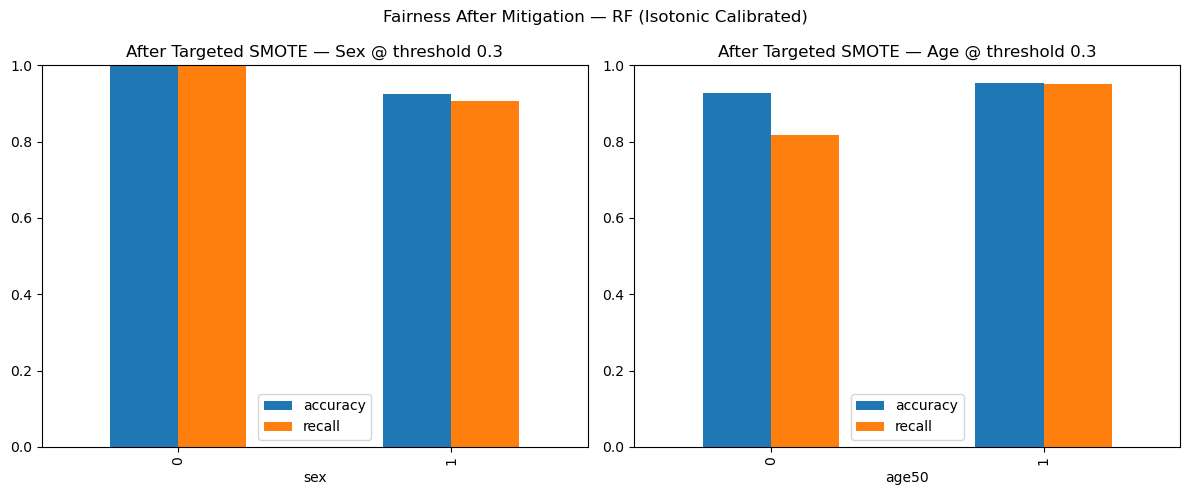

In [53]:
# --- 0) Assume you already have: X, y with ORIGINAL features only ---

# --- 1) Recreate the SAME split used for baseline (80–20) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# --- 2) Targeted SMOTE only within the FEMALE subgroup (sex==0), to balance positives ---
female_mask = (X_train["sex"] == 0)

X_f = X_train.loc[female_mask].copy()
y_f = y_train.loc[female_mask].copy()

X_m = X_train.loc[~female_mask].copy()
y_m = y_train.loc[~female_mask].copy()

# Within females, balance target classes (increase positive women)
smote_f = SMOTE(random_state=42)
X_f_bal, y_f_bal = smote_f.fit_resample(X_f, y_f)

# Recombine males (unchanged) + oversampled females
X_bal = pd.concat([X_m, X_f_bal], axis=0)
y_bal = pd.concat([y_m, y_f_bal], axis=0)

# Keep column order consistent
X_bal = X_bal[X_train.columns]

print("Train sizes — before:", X_train.shape, "after targeted SMOTE:", X_bal.shape)
print("Female counts before (neg,pos):", y_f.value_counts().sort_index().to_dict())
print("Female counts after  (neg,pos):", pd.Series(y_f_bal).value_counts().sort_index().to_dict())

# --- 3) Retrain RF on balanced data ---
rf_bal = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_bal.fit(X_bal, y_bal)

# --- 4) Recalibrate with isotonic on the balanced data ---
rf_bal_iso = CalibratedClassifierCV(rf_bal, method="isotonic", cv=5)
rf_bal_iso.fit(X_bal, y_bal)

# --- 5) Predictions on untouched test set (choose your clinical threshold) ---
THRESHOLD = 0.30
y_proba_bal = rf_bal_iso.predict_proba(X_test)[:, 1]
y_pred_bal  = (y_proba_bal >= THRESHOLD).astype(int)

# --- 6) Build aligned eval_df (avoid index issues) ---
eval_df_bal = pd.DataFrame({
    "y_true": y_test.reset_index(drop=True).values,
    "y_prob": pd.Series(y_proba_bal),
    "y_pred": pd.Series(y_pred_bal),
    "sex":    X_test["sex"].reset_index(drop=True).astype(int).values,      # 0=female, 1=male
    "age50":  (X_test["age"] >= 50).reset_index(drop=True).astype(int).values
})

# --- 7) Fairness tables (MetricFrame) ---
metrics = {
    "accuracy": accuracy_score,
    "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
    "recall": recall_score,
    "f1": f1_score,
    "selection_rate": selection_rate,
}

mf_sex_bal = MetricFrame(metrics=metrics,
                         y_true=eval_df_bal["y_true"],
                         y_pred=eval_df_bal["y_pred"],
                         sensitive_features=eval_df_bal["sex"])
mf_age_bal = MetricFrame(metrics=metrics,
                         y_true=eval_df_bal["y_true"],
                         y_pred=eval_df_bal["y_pred"],
                         sensitive_features=eval_df_bal["age50"])

print("\nAfter Targeted SMOTE — Performance by Sex (0=female, 1=male):")
display(mf_sex_bal.by_group)
print("\nAfter Targeted SMOTE — Performance by Age (0=<50, 1=≥50):")
display(mf_age_bal.by_group)

# --- 8) AUC by subgroup (computed with probabilities) ---
auc_by_sex_bal = eval_df_bal.groupby("sex").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
auc_by_age_bal = eval_df_bal.groupby("age50").apply(lambda g: roc_auc_score(g["y_true"], g["y_prob"]))
print("\nAUC by Sex after SMOTE:", auc_by_sex_bal.to_dict())
print("AUC by Age after SMOTE:", auc_by_age_bal.to_dict())

# --- 9) Quick disparity plots (accuracy & recall) ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))
mf_sex_bal.by_group[["accuracy","recall"]].plot(kind="bar", ax=axes[0])
axes[0].set_title(f"After Targeted SMOTE — Sex @ threshold {THRESHOLD}")
axes[0].set_ylim(0,1)

mf_age_bal.by_group[["accuracy","recall"]].plot(kind="bar", ax=axes[1])
axes[1].set_title(f"After Targeted SMOTE — Age @ threshold {THRESHOLD}")
axes[1].set_ylim(0,1)

plt.suptitle("Fairness After Mitigation — RF (Isotonic Calibrated)")
plt.tight_layout()
plt.show()


In [54]:
print(df['sex'].value_counts())

sex
1    389
0    184
Name: count, dtype: int64


In [55]:
# ====================== Predict + Explain (cleaned) ======================
import numpy as np, pandas as pd
from IPython.display import display
from sklearn.tree import _tree

# ---- pick calibrated model (prefers SMOTE-calibrated if available) ----
clf_cal = None
if 'rf_bal_iso' in globals():
    clf_cal = rf_bal_iso
elif 'rf_iso' in globals():
    clf_cal = rf_iso
else:
    raise RuntimeError("No calibrated model found. Train rf_iso or rf_bal_iso first.")

# ---- config ----
FEATURES   = list(X_train.columns)     # original feature order used for training
THRESHOLD  = 0.30
RISK_BINS  = [0.0, 0.20, 0.50, 1.0]
RISK_LABS  = ["Low (<20%)", "Moderate (20–50%)", "High (>50%)"]

# reasonable CF ranges (edit if needed)
PERMITTED_RANGE = {
    "age":[29,77], "trestbps":[90,200], "chol":[120,564], "thalach":[70,202], "oldpeak":[0.0,6.2],
    "sex":[0,1], "cp":[0,3], "fbs":[0,1], "restecg":[0,2], "exang":[0,1], "slope":[0,2], "ca":[0,4], "thal":[0,3]
}

# ---- helpers ----
def _coerce_input(user_dict: dict) -> pd.DataFrame:
    """Ensure correct column order & integer casting for categorical ints."""
    row = {f: user_dict.get(f, np.nan) for f in FEATURES}
    df_in = pd.DataFrame([row])[FEATURES].copy()
    int_like = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
    for c in int_like:
        if c in df_in.columns and pd.notnull(df_in.loc[0, c]):
            df_in[c] = int(round(float(df_in.loc[0, c])))
    return df_in

def _surrogate_path_explanation(df_in: pd.DataFrame) -> str:
    """Return the IF-THEN path that the small surrogate tree followed."""
    sur = globals().get("surrogate", None)
    if sur is None:
        return "Surrogate rules not available (train the surrogate tree first)."
    node_indicator = sur.decision_path(df_in)
    feat_idx = sur.tree_.feature
    thr = sur.tree_.threshold
    parts = []
    for node_id in node_indicator.indices:
        if feat_idx[node_id] != _tree.TREE_UNDEFINED:
            fname = FEATURES[feat_idx[node_id]]
            cut = thr[node_id]
            val = df_in.iloc[0, feat_idx[node_id]]
            parts.append(f"IF {fname} {'≤' if val <= cut else '>'} {cut:.2f} (value={val})")
    return " → ".join(parts) if parts else "Path not available."

def _shap_top(df_in: pd.DataFrame, top_k: int = 5):
    """Return top |SHAP| features; robust across SHAP versions and output shapes."""
    try:
        import shap
        base_rf = globals().get("rf_bal", None) or globals().get("rf", None)
        if base_rf is None:
            return "SHAP not available (need base RF variable: rf or rf_bal)."

        explainer = shap.TreeExplainer(base_rf)
        shap_vals = explainer.shap_values(df_in)

        # Cases:
        # - List[ndarray]: per-class arrays -> prefer class 1
        # - ndarray (2D): (n_samples, n_features) -> take row 0
        # - ndarray (3D): (n_samples, n_features, n_classes) -> take row 0, class 1
        if isinstance(shap_vals, list):
            vals = shap_vals[1][0] if len(shap_vals) > 1 else shap_vals[0][0]
        else:
            arr = np.asarray(shap_vals)
            if arr.ndim == 3:
                vals = arr[0, :, 1] if arr.shape[2] > 1 else arr[0, :, 0]
            elif arr.ndim == 2:
                vals = arr[0, :]
            else:  # 1D fallback
                vals = arr

        s = pd.Series(vals, index=FEATURES).abs().sort_values(ascending=False).head(top_k)
        return s.to_frame("abs_SHAP").T
    except Exception as e:
        return f"SHAP not available: {e}"


def _counterfactual(df_in: pd.DataFrame, total: int = 2):
    """Generate counterfactuals limited to actionable features."""
    try:
        import warnings, dice_ml
        warnings.filterwarnings("ignore", category=FutureWarning)

        # Build training frame for DiCE
        train_df_for_dice = X_train.copy()
        train_df_for_dice["target"] = y_train.values

        # Choose actionable features (edit as you prefer)
        ACTIONABLE = ["trestbps", "chol", "thalach", "oldpeak", "exang", "fbs"]
        IMMUTABLE  = ["sex", "age"]  # never change
        # If you want to also freeze test-only fields:
        # IMMUTABLE += ["ca", "thal", "restecg", "cp", "slope"]

        # DiCE needs to know which are continuous
        continuous = [c for c in ACTIONABLE if c in ["age","trestbps","chol","thalach","oldpeak","ca"]]

        d = dice_ml.Data(dataframe=train_df_for_dice,
                         continuous_features=continuous,
                         outcome_name="target")
        m = dice_ml.Model(model=clf_cal, backend="sklearn")
        exp = dice_ml.Dice(d, m, method="random")

        base_prob = float(clf_cal.predict_proba(df_in)[:, 1][0])
        desired_numeric = 0 if base_prob >= THRESHOLD else 1

        cf = exp.generate_counterfactuals(
            df_in,
            total_CFs=total,
            desired_class=desired_numeric,
            features_to_vary=ACTIONABLE,   # <<— only actionable features allowed to change
            # permitted_range can optionally constrain numeric ranges; safe to omit if you see dtype nags
            # permitted_range=PERMITTED_RANGE,
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df[FEATURES]

        # Make a delta table but ignore immutable changes (shouldn’t exist now)
        base = df_in.iloc[0]
        deltas = []
        for _, row in cf_df.iterrows():
            chg = {}
            for f in FEATURES:
                if f in IMMUTABLE:
                    continue
                if f in cf_df.columns and row[f] != base[f]:
                    chg[f] = f"{base[f]} → {row[f]}"
            deltas.append(chg if chg else {"note": "No changes"})
        return cf_df, pd.DataFrame(deltas)

    except Exception as e:
        return None, f"Counterfactual not available: {e}"


# ---- main entry ----------------------------------------------------------
def predict_and_explain(user_input: dict, threshold: float = THRESHOLD):
    """Compute calibrated risk + decision + risk band, show rules, SHAP & counterfactuals."""
    df_in = _coerce_input(user_input)

    # Probability, decision, risk band
    prob = float(clf_cal.predict_proba(df_in)[:,1][0])
    decision = int(prob >= threshold)
    bucket = pd.cut([prob], bins=RISK_BINS, labels=RISK_LABS, include_lowest=True)[0]

    print(f"Calibrated risk: {prob:.3f}  |  Decision @ {threshold:.2f}: {decision}  |  Risk band: {bucket}")

    # Surrogate path
    print("\nSurrogate rule path (approx. RF decision):")
    print(" ", _surrogate_path_explanation(df_in))

    # SHAP importance (optional)
    print("\nTop features by SHAP (base RF):")
    display(_shap_top(df_in))

    # Counterfactuals
    print("\nCounterfactual suggestions (values) — minimal changes to flip/reduce risk:")
    cf_tab, delta_tab = _counterfactual(df_in, total=2)
    display(cf_tab if isinstance(cf_tab, pd.DataFrame) else cf_tab)
    print("\nCounterfactual action plan (what to change):")
    display(delta_tab if isinstance(delta_tab, pd.DataFrame) else delta_tab)

    return {"input_df": df_in, "prob": prob, "decision": decision, "risk_band": str(bucket)}

# ---- Example (edit values or drive via your UI form) ----
# example_patient = {
#     "age": 56, "sex": 0, "cp": 3, "trestbps": 140, "chol": 250,
#     "fbs": 0, "restecg": 1, "thalach": 150, "exang": 0,
#     "oldpeak": 1.2, "slope": 2, "ca": 0, "thal": 2,
# }
# res = predict_and_explain(example_patient)


In [56]:
# ===== User Input UI with labeled options + Feature Guide =====
import ipywidgets as w
from IPython.display import display, clear_output, HTML

# Mappings with human-friendly labels
CP_OPTIONS = [
    ("0 — typical angina", 0),
    ("1 — atypical angina", 1),
    ("2 — non-anginal pain", 2),
    ("3 — asymptomatic", 3),
]
RESTECG_OPTIONS = [
    ("0 — normal", 0),
    ("1 — ST-T wave abnormality (>0.05 mV)", 1),
    ("2 — probable/definite LVH (Estes’ criteria)", 2),
]
SEX_OPTIONS = [("Female (0)", 0), ("Male (1)", 1)]
FBS_OPTIONS = [("≤ 120 mg/dL (0)", 0), ("> 120 mg/dL (1)", 1)]
EXANG_OPTIONS = [("No (0)", 0), ("Yes (1)", 1)]
SLOPE_OPTIONS = [
    ("0 — upsloping", 0),
    ("1 — flat", 1),
    ("2 — downsloping", 2),
]
# Note: your note said "ca: The number of major vessels (0–3)" but many cleaned datasets allow up to 4.
CA_MIN, CA_MAX = 0, 4
THAL_OPTIONS = [
    ("0 — NULL", 0),
    ("1 — normal blood flow", 1),
    ("2 — fixed defect", 2),
    ("3 — reversible defect", 3),
]

# Reasonable numeric bounds (used for sliders)
AGE_MIN, AGE_MAX = 29, 77
BP_MIN, BP_MAX = 90, 200
CHOL_MIN, CHOL_MAX = 120, 564
THALACH_MIN, THALACH_MAX = 70, 202
OLDPEAK_MIN, OLDPEAK_MAX = 0.0, 6.2

# Build widgets
inputs = {
    "age": w.IntSlider(value=56, min=AGE_MIN, max=AGE_MAX, step=1, description="Age"),
    "sex": w.Dropdown(options=SEX_OPTIONS, value=0, description="Sex"),
    "cp": w.Dropdown(options=CP_OPTIONS, value=3, description="Chest pain (cp)"),
    "trestbps": w.IntSlider(value=140, min=BP_MIN, max=BP_MAX, step=1, description="Rest BP"),
    "chol": w.IntSlider(value=250, min=CHOL_MIN, max=CHOL_MAX, step=1, description="Cholesterol"),
    "fbs": w.Dropdown(options=FBS_OPTIONS, value=0, description="Fasting BS"),
    "restecg": w.Dropdown(options=RESTECG_OPTIONS, value=1, description="Rest ECG"),
    "thalach": w.IntSlider(value=150, min=THALACH_MIN, max=THALACH_MAX, step=1, description="Max HR"),
    "exang": w.Dropdown(options=EXANG_OPTIONS, value=0, description="Exercise angina"),
    "oldpeak": w.FloatSlider(value=1.2, min=OLDPEAK_MIN, max=OLDPEAK_MAX, step=0.1, description="Oldpeak"),
    "slope": w.Dropdown(options=SLOPE_OPTIONS, value=2, description="ST slope"),
    "ca": w.IntSlider(value=0, min=CA_MIN, max=CA_MAX, step=1, description="Major vessels (ca)"),
    "thal": w.Dropdown(options=THAL_OPTIONS, value=2, description="Thalassemia"),
}

# Layout helpers
def row(lbl, widget):
    lbl_w = w.HTML(f"<b>{lbl}</b>", layout=w.Layout(width="200px"))
    return w.HBox([lbl_w, widget])

form = w.VBox([
    row("Age (years)", inputs["age"]),
    row("Sex", inputs["sex"]),
    row("Chest pain type (cp)", inputs["cp"]),
    row("Resting BP (mmHg)", inputs["trestbps"]),
    row("Cholesterol (mg/dL)", inputs["chol"]),
    row("Fasting blood sugar (fbs)", inputs["fbs"]),
    row("Resting ECG (restecg)", inputs["restecg"]),
    row("Max heart rate (thalach)", inputs["thalach"]),
    row("Exercise-induced angina (exang)", inputs["exang"]),
    row("ST depression (oldpeak)", inputs["oldpeak"]),
    row("ST slope during peak exercise (slope)", inputs["slope"]),
    row("Major vessels (ca)", inputs["ca"]),
    row("Thalassemia (thal)", inputs["thal"]),
])

# Feature guide content
guide_html = """
<div style="line-height:1.5; font-size:14px">
  <h4>Feature Guide</h4>
  <ul>
    <li><b>Age</b>: Patient age in years.</li>
    <li><b>Sex</b>: Male = 1, Female = 0.</li>
    <li><b>cp (Chest pain type)</b>:
      <ul>
        <li>0 — typical angina</li>
        <li>1 — atypical angina</li>
        <li>2 — non-anginal pain</li>
        <li>3 — asymptomatic</li>
      </ul>
    </li>
    <li><b>trestbps</b>: Resting blood pressure (mmHg).</li>
    <li><b>chol</b>: Serum cholesterol (mg/dL).</li>
    <li><b>fbs</b>: Fasting blood sugar &gt; 120 mg/dL → 1, else 0.</li>
    <li><b>restecg</b>:
      <ul>
        <li>0 — normal</li>
        <li>1 — ST-T wave abnormality (&gt; 0.05 mV)</li>
        <li>2 — probable/definite LVH (Estes’ criteria)</li>
      </ul>
    </li>
    <li><b>thalach</b>: Maximum heart rate achieved.</li>
    <li><b>exang</b>: Exercise-induced angina (Yes=1, No=0).</li>
    <li><b>oldpeak</b>: ST-depression relative to rest.</li>
    <li><b>slope</b> (ST segment slope at peak exercise):
      <ul>
        <li>0 — upsloping</li>
        <li>1 — flat</li>
        <li>2 — downsloping</li>
      </ul>
    </li>
    <li><b>ca</b>: Number of major vessels colored by fluoroscopy (0–3; some datasets include 4).</li>
    <li><b>thal</b>:
      <ul>
        <li>0 — NULL</li>
        <li>1 — normal blood flow</li>
        <li>2 — fixed defect</li>
        <li>3 — reversible defect</li>
      </ul>
    </li>
    <li><b>target</b> (label): 1 = heart disease, 0 = normal.</li>
  </ul>
</div>
"""
guide = w.Accordion(children=[w.HTML(guide_html)])
guide.set_title(0, "Feature Guide (click to expand)")

# Run button + output
run_btn = w.Button(description="Predict & Explain", button_style="primary", icon="heartbeat")
out = w.Output()

def on_click(_):
    with out:
        clear_output()
        # collect values in the exact feature order your model expects
        vals = {k: v.value for k, v in inputs.items()}
        predict_and_explain(vals)

display(guide, form, run_btn, out)
run_btn.on_click(on_click)


Accordion(children=(HTML(value='\n<div style="line-height:1.5; font-size:14px">\n  <h4>Feature Guide</h4>\n  <…

Button(button_style='primary', description='Predict & Explain', icon='heartbeat', style=ButtonStyle())

Output()